# MNIST Digit Classification System

## Business Problem

A document-processing company receives thousands of handwritten forms daily.

Manual digit recognition is slow, expensive, and error-prone.

The company wants an automated system capable of recognizing handwritten digits from scanned images.

## Machine Learning Objective

Build a classification model that predicts the digit represented in an image.

### Phase 1

Start with a binary classification problem:

```text
Is the digit a 5?

In [7]:
from sklearn.datasets import fetch_openml
mnist=fetch_openml("mnist_784",as_frame=False)
X,y=mnist.data, mnist.target
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


### Explanation

We load the MNIST dataset from OpenML.

Feature Matrix:

```text
X

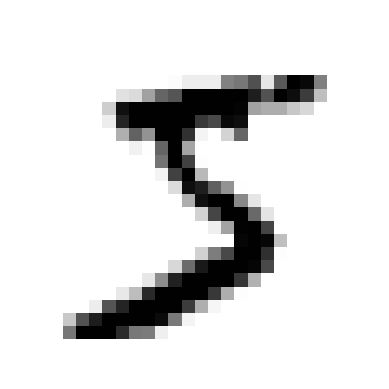

Label 5


In [10]:
import matplotlib.pyplot as plt
some_digit=X[0]
some_digit_image=some_digit.reshape(28,28)
plt.imshow(some_digit_image,cmap="binary")
plt.axis("off")
plt.show()
print("Label",y[0])

### Why This Step?

Before training any model, verify what the raw data actually represents.

As ML Engineers, never assume dataset documentation is correct.

Common production practice:

- Inspect samples
- Verify labels
- Check shapes
- Confirm data quality early

This is the first sanity check of the dataset.

In [11]:
y=y.astype(int)
print(type(y[0]))
print(y[:10])

<class 'numpy.int64'>
[5 0 4 1 9 2 1 3 1 4]


### Why Convert Labels?

OpenML loads labels as strings.

Most scikit-learn algorithms expect numeric targets.

Converting once at the start prevents downstream issues during training and evaluation.

## testing on single digit 5 

In [12]:
X_train, X_test=X[:60000],X[60000:]
y_train,y_test=y[:60000],y[60000:]

y_train_5=y_train==5
y_test_5=y_test==5

print(X_train.shape,X_test.shape)
print(y_train_5[:10])

(60000, 784) (10000, 784)
[ True False False False False False False False False False]


### What We Did

MNIST is already ordered into train and test sets.

We created a binary target:

```text
True  = digit is 5
False = digit is not 5

In [13]:
from sklearn.linear_model import SGDClassifier

sgd_clf=SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train_5)

sgd_clf.predict([some_digit])

array([ True])

### Model Used

We train an SGDClassifier.

SGD means Stochastic Gradient Descent.

It is useful when:

- dataset is large
- training needs to be fast
- model may be updated incrementally later

Here it learns a binary decision boundary:

```text
5 vs Not-5

In [14]:
from sklearn.model_selection import cross_val_score
accuracy_scores=cross_val_score(
    sgd_clf,
    X_train,
    y_train_5,
    cv=3,
    scoring="accuracy"
)
accuracy_scores

array([0.95035, 0.96035, 0.9604 ])

### Why Accuracy First?

Accuracy tells how many predictions were correct.

But for this problem, most digits are not 5.

So a model can get high accuracy by simply predicting:

```text
Not-5

In [15]:
from sklearn.dummy import DummyClassifier
dummy_clf=DummyClassifier(strategy="most_frequent")
dummy_scores=cross_val_score(
    dummy_clf,
    X_train,
    y_train_5,
    cv=3,
    scoring="accuracy"
)
dummy_scores

array([0.90965, 0.90965, 0.90965])

### Why This Baseline Matters

The dummy model always predicts the majority class:

```text
Not-5

In [16]:
from sklearn.model_selection import cross_val_predict
y_train_pred=cross_val_predict(
    sgd_clf,
    
    X_train,
    y_train_5,
    cv=3
)
y_train_pred[:10]

array([ True, False, False, False, False, False, False, False, False,
       False])

### Why cross_val_predict?

cross_val_score returns only evaluation scores.

cross_val_predict returns predictions for every training instance as if that instance had never been seen during training.

This allows us to compute:

- Confusion Matrix
- Precision
- Recall
- F1 Score

which require actual predictions.

In [17]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_train_5,y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

In [18]:
from sklearn.metrics import precision_score
precision=precision_score(y_train_5, y_train_pred)
precision

0.8370879772350012

### Precision

Question:

When the model predicts:

```text
5
how often is it correct?

Formula:

TP / (TP + FP)

High precision means:

Few false alarms.

Use cases:

Spam detection
Fraud alerts
Expensive manual review systems

where false positives are costly.

Run and send the value. Then we'll do Recall and you'll immediately see the tradeoff.

In [19]:
from sklearn.metrics import recall_score
recall=recall_score(y_train_5,y_train_pred)
recall

0.6511713705958311

### Recall

Question:

Out of all actual 5s,

how many did we successfully find?

Formula:

TP / (TP + FN)

High recall means:

Few missed positive cases.

Important for:

- Cancer detection
- Fraud detection
- Security threats
- Defect detection

where missing a true positive is expensive.

## Now we have the first real insight.

Precision = 83.7%
Recall    = 65.1%

## Interpretation:

Precision
Model says "5"
↓
83.7% chance it is actually 5

Good.

Recall
All actual 5s in dataset
↓
Model found only 65.1% of them

Not great.

It missed:

FN = 1891

actual 5s.

## Why Precision and Recall Fight Each Other

Imagine making the classifier stricter.

Only predict 5 when extremely confident.

Result:

Precision ↑
Recall ↓

Because:

fewer false positives
more missed 5s

Imagine making it lenient.

Predict 5 more often.

Result:

Precision ↓
Recall ↑

Because:

more true positives
more false positives

This is called:

Precision-Recall Tradeoff

One of the most common ML interview topics.

In [20]:
from sklearn.metrics import f1_score
f1=f1_score(y_train_5, y_train_pred)
f1

0.7325171197343847

### F1 Score

F1 combines Precision and Recall into a single metric.

Formula:

2 × (Precision × Recall)
-------------------------
 Precision + Recall

Use F1 when:

- Both false positives and false negatives matter.
- Accuracy is misleading.
- Dataset is imbalanced.

A high F1 requires both Precision and Recall to be good.

## Good.

Precision = 0.837
Recall    = 0.651
F1        = 0.733
## What F1 Actually Means

F1 is not an average.

It punishes imbalance.

Example:

Precision = 99%
Recall    = 10%

F1 would still be poor.

## Why?

Because a good classifier should not be excellent in one metric and terrible in the other.

Interview Takeaway

If interviewer asks:

Why not accuracy?

## Answer:

Accuracy ignores class imbalance.

Confusion Matrix shows mistakes.

Precision measures false positives.

Recall measures false negatives.

F1 balances both precision and recall.

That's enough for most interviews.

In [21]:
y_scores=sgd_clf.decision_function([some_digit])

y_scores

array([2164.22030239])

### Why Decision Scores Matter

A classifier usually produces a confidence score first.

Prediction is created by applying a threshold.

Default behavior:

score > 0 → Positive Class
score <= 0 → Negative Class

Production systems often modify this threshold instead of retraining the model.

Examples:

- Fraud detection
- Spam filtering
- Medical diagnosis
- Security systems

Changing the threshold changes Precision and Recall.

In [22]:
threshold=0
y_some_digit_pred=y_scores>threshold

y_some_digit_pred

array([ True])

### Threshold = 0

At the default threshold, the score is positive.

So the model classifies this image as:

```text
5

In [23]:
threshold=3000
y_some_digit_pred=y_scores>threshold
y_some_digit_pred

array([False])

### Higher Threshold

When we increase the threshold, the classifier becomes stricter.

Result:

- Precision usually increases
- Recall usually decreases

This same image may now be rejected as not-5.

In [25]:
y_scores=cross_val_predict(
    sgd_clf,
    X_train,
    y_train_5,
    cv=3,
    method="decision_function"
)
y_scores[:10]

array([  1200.93051237, -26883.79202424, -33072.03475406, -15919.5480689 ,
       -20003.53970191, -16652.87731528, -14276.86944263, -23328.13728948,
        -5172.79611432, -13873.5025381 ])

### Why Do This?

Earlier:

```python
cross_val_predict(...)
gave predictions.

Now:

method="decision_function"

returns decision scores for every sample.

These scores allow us to:

Change thresholds
Plot Precision-Recall curves
Plot ROC curves
Select business-specific operating points

In [26]:
from sklearn.metrics import precision_recall_curve
precisions,recalls,thresholds=precision_recall_curve(y_train_5,y_scores)

print(len(precisions))
print(len(recalls))
print(len(thresholds))

60001
60001
60000


### What Does precision_recall_curve() Do?

Instead of testing one threshold:

```text
0
it tests thousands of thresholds automatically.

For each threshold it computes:

Precision
Recall

This lets us understand the behavior of the classifier across all operating points.

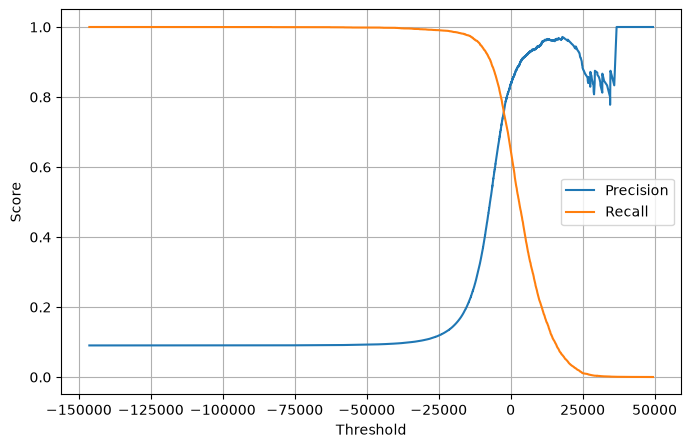

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)

plt.show()

### How To Read This Graph

As threshold increases:

Recall usually falls.

Why?

The classifier becomes stricter and misses more true positives.

Precision usually rises.

Why?

Only highly confident predictions are accepted.

This tradeoff exists in almost every classification system.



## Interview / ML Engineer Connection

Suppose you're building:

Resume Screening System

## If HR says:

Never miss good candidates

Optimize for:

High Recall

## If HR says:

Don't send us bad candidates

Optimize for:

High Precision

## If interviewer asks:

We need 95% precision. Do we retrain the model?

## Answer:

Not necessarily.

First adjust the decision threshold.

Threshold tuning is often done before retraining.

In [28]:
idx_for_90_precision=(precisions>=.90).argmax()
threshold_for_90_precision=thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3370.0194991439557)

### Why Are We Doing This?

Suppose the business says:

```text
At least 90% precision required

In [30]:
y_train_pred_90=y_scores>=threshold_for_90_precision

### New Prediction Rule

Old rule:

score >= 0

New rule:

score >= 3370

The classifier now requires much stronger evidence before predicting 5.

In [31]:
precision_score(y_train_5,y_train_pred_90)

0.9000345901072293

In [32]:
recall_score(y_train_5,y_train_pred_90)


0.4799852425751706

In [34]:
from sklearn.metrics import roc_curve
fpr,tpr, thresholds=roc_curve(y_train_5,y_scores)

print(len(fpr))
print(len(tpr))

3908
3908


### What roc_curve() Returns

For many thresholds it computes:

- False Positive Rate
- True Positive Rate

These values are used to draw the ROC curve.

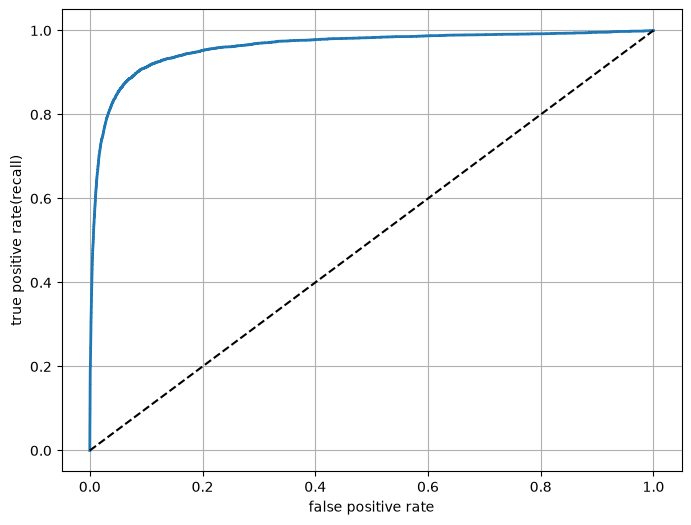

In [35]:
import matplotlib.pyplot as ply

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,linewidth=2)
plt.plot([0,1],[0,1],"k--")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate(recall)")
plt.grid(True)
plt.show()

### How To Read ROC

Closer to the top-left corner:

```text
Good classifier

In [39]:
from sklearn.metrics import roc_auc_score
roc_auc=roc_auc_score(
    y_train_5,
    y_scores
)
roc_auc

0.9604938554008616

### ROC-AUC

ROC-AUC summarizes the entire ROC curve into a single number.

Higher ROC-AUC means the classifier separates positive and negative classes better across many thresholds.

General interpretation:

- 0.5 = random guessing
- 0.7 = fair
- 0.8 = good
- 0.9+ = excellent
- 1.0 = perfect

In [40]:
from sklearn.ensemble import RandomForestClassifier
forest_clf=RandomForestClassifier(
    random_state=42
)
y_probas_forest=cross_val_predict(
    forest_clf,
    X_train,
    y_train_5,
    cv=3,
    method="predict_proba"
)

### Why Another Model?

Metrics are useful only when comparing alternatives.

Now we train a Random Forest and compare it with SGD.

This mirrors real ML work:

- Train multiple candidates
- Evaluate
- Select best model

In [41]:
y_probas_forest.shape

(60000, 2)

In [44]:
y_scores_forest=y_probas_forest[:,1]
y_scores_forest[:5]

array([0.89, 0.01, 0.04, 0.  , 0.01])

### Why Column 1?

predict_proba returns:

[ P(Not-5), P(5) ]

We need the probability of the positive class (5).

In [46]:
from sklearn.metrics import roc_auc_score
forest_auc=roc_auc_score(
    y_train_5,
    y_scores_forest
)
forest_auc

0.9983436731328145

### Model Comparison

Now we compare:

- SGD ROC-AUC
- Random Forest ROC-AUC

Higher ROC-AUC generally indicates better class separation.